# 🥥 Plan financiero a 24 meses · Cocoil

**Proyecto:** coco-analytics · **Notebook 03** · julio 2026

Responde las tres preguntas que siguen al punto de equilibrio (notebook 02):

1. **¿Cuánta plata hay que poner** para arrancar (inversión + capital de trabajo)?
2. **¿Cuándo se recupera** (payback)?
3. **¿Cuál es el punto de máxima necesidad de caja** (el "valle") que hay que tener financiado antes de empezar?

> ⚠️ Igual que el notebook 02: los precios de competencia y el CIF son **datos**;
> los costos y la **rampa de ventas** son **supuestos editables** en la §2.
> La rampa es la variable nueva más incierta — probá escenarios.


## 1. Preparación

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

BASE = Path.cwd()
ANALISIS = BASE if (BASE / "datos").exists() else BASE / "analisis"
sys.path.append(str(ANALISIS.parent / "src"))
from estilo import aplicar_estilo, guardar, COCO
aplicar_estilo()
print("Listo")


Listo


## 2. ⚙️ Supuestos — EDITÁ ESTA CELDA

Consistentes con el notebook 02 (mismo costo variable y fijos). Lo nuevo: inversión inicial y rampa de ventas.

In [2]:
F = {
    # --- Inversión inicial (antes del mes 1) ---
    "prensa_usd": 2500,            # la prensa que ya estás comprando
    "acondicionamiento_bs": 8000,  # adecuación del taller (mesones, lavado, pintura sanitaria)
    "equipamiento_menor_bs": 3500, # filtros, recipientes, balanza, utensilios inox
    "tramites_bs": 1500,           # SENASAG artesanal (500) + SEPREC/NIT/licencia (~1000, ver investigación legal)
    "stock_inicial_bs": 4000,      # primera compra de cocos + frascos + etiquetas

    # --- Operación (del notebook 02) ---
    "costo_variable_frasco_bs": 19.6,   # frasco 200 ml (§3 del notebook 02)
    "fijos_bs_mes": 7000,               # incluye amortización de prensa
    "precio_venta_bs": 55.0,            # frasco 200 ml

    # --- Rampa de ventas (frascos de 200 ml por mes) ---
    "ventas_mes_1": 60,       # arranque: amigos, ferias, redes
    "crecimiento_mensual_pct": 18,  # % de crecimiento mensual mientras haya mercado
    "tope_frascos_mes": 650,  # techo por capacidad artesanal y tamaño del nicho

    "tc_bs_usd": 6.96,
    "meses": 24,
}
inversion_inicial = (F["prensa_usd"] * F["tc_bs_usd"] + F["acondicionamiento_bs"]
                     + F["equipamiento_menor_bs"] + F["tramites_bs"] + F["stock_inicial_bs"])
print(f"Inversión inicial: Bs {inversion_inicial:,.0f} (≈ US$ {inversion_inicial/F['tc_bs_usd']:,.0f})")


Inversión inicial: Bs 34,400 (≈ US$ 4,943)


## 3. Flujo de caja mensual

Ventas con rampa (crecen 18% por mes hasta el tope), margen unitario del notebook 02, fijos constantes.
El mes 0 es la inversión inicial.

In [3]:
meses = np.arange(0, F["meses"] + 1)
ventas = [0]
for m in range(1, F["meses"] + 1):
    v = F["ventas_mes_1"] * (1 + F["crecimiento_mensual_pct"]/100) ** (m - 1)
    ventas.append(min(v, F["tope_frascos_mes"]))
ventas = np.array(ventas)

ingresos = ventas * F["precio_venta_bs"]
c_var = ventas * F["costo_variable_frasco_bs"]
fijos = np.where(meses == 0, 0, F["fijos_bs_mes"])
flujo = ingresos - c_var - fijos
flujo[0] = -inversion_inicial
caja = flujo.cumsum()

df = pd.DataFrame({"mes": meses, "frascos": ventas.round(0), "ingresos": ingresos.round(0),
                   "costo_variable": c_var.round(0), "fijos": fijos, "flujo": flujo.round(0),
                   "caja_acumulada": caja.round(0)})
display(df.head(8))
payback = next((int(m) for m, c in zip(meses, caja) if c > 0), None)
valle = caja.min()
print(f"Payback: mes {payback} · Valle de caja: Bs {valle:,.0f} (la plata total que hay que tener)")


,mes,frascos,ingresos,costo_variable,fijos,flujo,caja_acumulada
0,0,0.0,0.0,0.0,0,-34400.0,-34400.0
1,1,60.0,3300.0,1176.0,7000,-4876.0,-39276.0
2,2,71.0,3894.0,1388.0,7000,-4494.0,-43770.0
3,3,84.0,4595.0,1637.0,7000,-4043.0,-47812.0
4,4,99.0,5422.0,1932.0,7000,-3510.0,-51322.0
5,5,116.0,6398.0,2280.0,7000,-2882.0,-54204.0
6,6,137.0,7550.0,2690.0,7000,-2141.0,-56345.0
7,7,162.0,8909.0,3175.0,7000,-1266.0,-57611.0


Payback: mes 16 · Valle de caja: Bs -57,845 (la plata total que hay que tener)


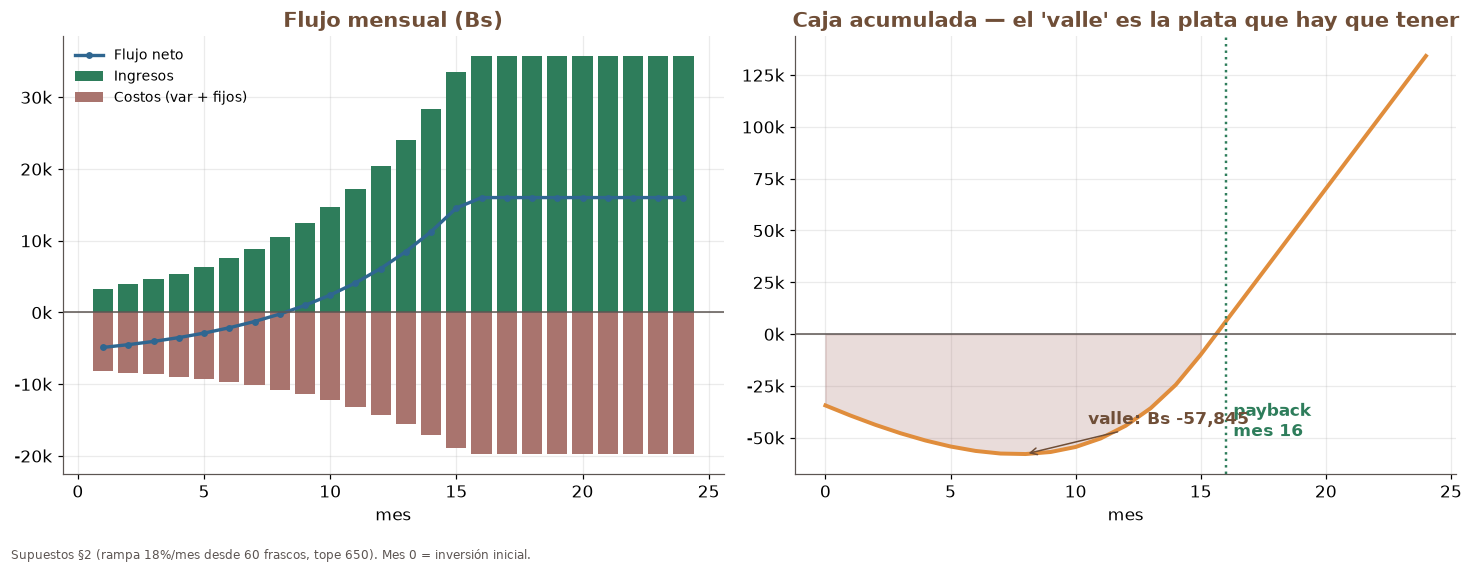

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

m1 = meses[1:]
axes[0].bar(m1, ingresos[1:], color=COCO["verde"], label="Ingresos")
axes[0].bar(m1, -(c_var[1:] + fijos[1:]), color=COCO["marron_claro"], label="Costos (var + fijos)")
axes[0].plot(m1, flujo[1:], color=COCO["azul"], linewidth=2.2, marker="o", markersize=3.5, label="Flujo neto")
axes[0].axhline(0, color=COCO["gris"], linewidth=1)
axes[0].set_title("Flujo mensual (Bs)")
axes[0].set_xlabel("mes")
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v/1000:,.0f}k"))

axes[1].plot(meses, caja, color=COCO["acento"], linewidth=2.6)
axes[1].fill_between(meses, caja, 0, where=caja < 0, color=COCO["marron_claro"], alpha=0.25)
axes[1].axhline(0, color=COCO["gris"], linewidth=1)
if payback:
    axes[1].axvline(payback, color=COCO["verde"], linestyle=":", linewidth=1.6)
    axes[1].text(payback + 0.3, caja.min()*0.85, f"payback\nmes {payback}", color=COCO["verde"], fontweight="bold")
axes[1].annotate(f"valle: Bs {valle:,.0f}", xy=(np.argmin(caja), valle),
                 xytext=(np.argmin(caja)+2.5, valle*0.75), color=COCO["marron"], fontweight="bold",
                 arrowprops={"arrowstyle": "->", "color": COCO["marron"]})
axes[1].set_title("Caja acumulada — el 'valle' es la plata que hay que tener")
axes[1].set_xlabel("mes")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v/1000:,.0f}k"))

plt.figtext(0.01, -0.03, "Supuestos §2 (rampa 18%/mes desde 60 frascos, tope 650). Mes 0 = inversión inicial.",
            fontsize=8, color=COCO["gris"])
plt.tight_layout()
guardar("14_flujo_caja")
plt.show()


## 4. Escenarios de rampa — la variable más incierta

La rampa de ventas es una apuesta. Tres escenarios para acotar el riesgo:

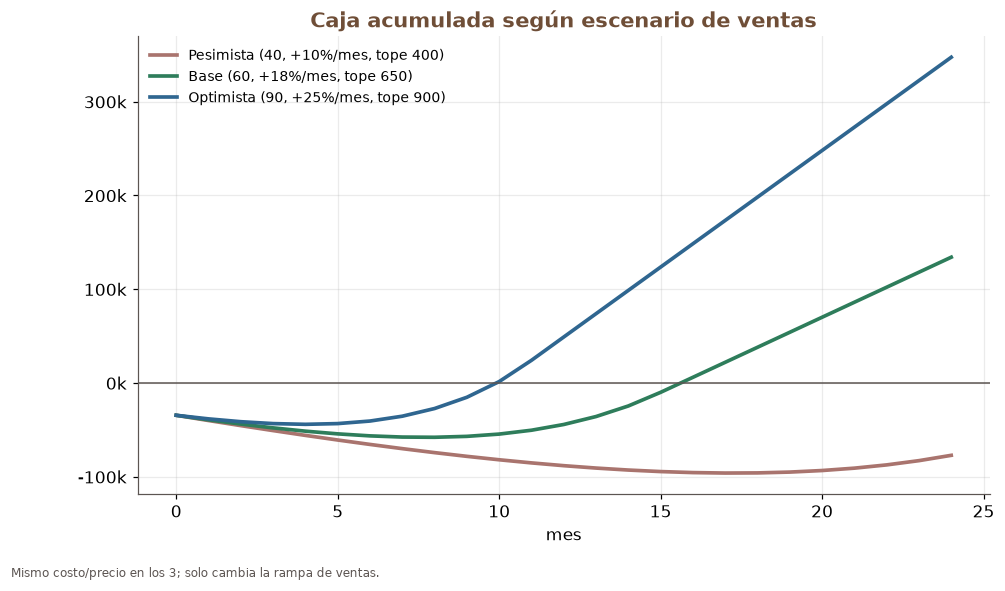

,Escenario,Payback (mes),Valle de caja (Bs),Caja mes 24 (Bs)
0,Pesimista,>24,"-95,989","-77,088"
1,Base,16,"-57,845","134,180"
2,Optimista,10,"-44,031","347,396"


In [5]:
def simular(v1, crec, tope):
    vs = [0] + [min(v1 * (1 + crec/100) ** (m - 1), tope) for m in range(1, F["meses"] + 1)]
    vs = np.array(vs)
    fl = vs * (F["precio_venta_bs"] - F["costo_variable_frasco_bs"]) - np.where(meses == 0, 0, F["fijos_bs_mes"])
    fl[0] = -inversion_inicial
    cj = fl.cumsum()
    pb = next((int(m) for m, c in zip(meses, cj) if c > 0), None)
    return cj, pb

escenarios = {
    "Pesimista (40, +10%/mes, tope 400)": (40, 10, 400, COCO["marron_claro"]),
    "Base (60, +18%/mes, tope 650)": (60, 18, 650, COCO["verde"]),
    "Optimista (90, +25%/mes, tope 900)": (90, 25, 900, COCO["azul"]),
}
fig, ax = plt.subplots(figsize=(10, 5.4))
resumen = []
for nombre, (v1, cr, tp, color) in escenarios.items():
    cj, pb = simular(v1, cr, tp)
    ax.plot(meses, cj, linewidth=2.4, color=color, label=nombre)
    resumen.append({"Escenario": nombre.split(" (")[0], "Payback (mes)": pb if pb else ">24",
                    "Valle de caja (Bs)": f"{cj.min():,.0f}", "Caja mes 24 (Bs)": f"{cj[-1]:,.0f}"})
ax.axhline(0, color=COCO["gris"], linewidth=1)
ax.set_title("Caja acumulada según escenario de ventas")
ax.set_xlabel("mes")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v/1000:,.0f}k"))
ax.legend(fontsize=9)
plt.figtext(0.01, -0.03, "Mismo costo/precio en los 3; solo cambia la rampa de ventas.", fontsize=8, color=COCO["gris"])
guardar("15_escenarios")
plt.show()
display(pd.DataFrame(resumen))


## 5. Conclusiones

| Pregunta | Escenario base |
|---|---|
| **Inversión + trámites + stock inicial** | **~Bs 34.400 (≈ US$ 4.900)** |
| **Valle de caja** (máxima necesidad) | el valle del gráfico §3 — es LA cifra a financiar, mayor que la inversión inicial |
| **Payback** | ver §3 (base) y §4 (rango pesimista-optimista) |
| **Sensibilidad** | La rampa manda: en pesimista el payback se va más allá del año — validar demanda ANTES de invertir en escala |

### Lectura estratégica
- El negocio es de **inversión chica y margen alto**: el riesgo no es la plata inicial sino
  la **velocidad de venta** (nicho de 40–100 t/año importadas + producción local artesanal).
- **Presupuestá el valle, no la inversión**: quedarse sin caja en el mes 6 con el negocio
  funcionando es el error clásico.
- La rampa base (60 → 650 frascos/mes en 2 años) implica capturar una parte relevante del
  nicho — el notebook 04 (demanda) la contrasta con el tamaño real del mercado.

> Todos los números se recalculan editando la §2 (`Kernel → Restart & Run All`).
